# §10 · CIFAR-10 Architecture Search — Round 2

**Goal**: find the **smallest** plain CNN (no residual connections) that reaches ≥ 90 % test accuracy on CIFAR-10.

**Round 1 findings**: architecture is the bottleneck (TinyCNN 70.6 % → SmallCNN_orig 85.8 %); training config explains only ~0.4 pp. The 94k-param WideCNN_GAP matches the 156k SmallCNN_orig, confirming GAP is more efficient than a large FC head.

**Round 2 sweep**: 4 deeper/wider architectures × 2 training configs = 8 experiments (leaner than Round 1).  
Training configs: `baseline` (150 ep) as reference; `strong` (200 ep + ColorJitter + 16 × 16 CutOut) as best effort.

| step | what happens |
|------|--------------|
| §2 | load CIFAR-10 |
| §3 | build architecture variants, compare parameter counts |
| §4–5 | define training loop and run sweep |
| §6–8 | results table, training curves, ablation bars |
| §9–11 | select winner, save, verify round-trip load |

In [1]:
import sys, time, json, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src import SmallCNN, save_experiment, load_experiment
from src.data_utils import get_cifar10_loaders

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('cpu')
)
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}")

Device:  mps
PyTorch: 2.11.0


## §2  Data

100.0%


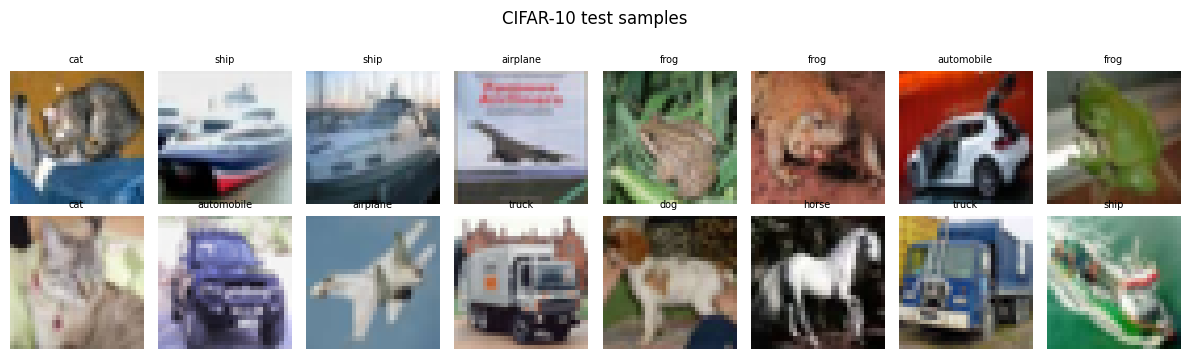

Test batches: 40  |  Test samples: 10000


In [3]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Smoke-test: load one batch from test set and show a grid.
_, test_loader = get_cifar10_loaders(batch_size=256, augment='baseline')

_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
_std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

imgs, labels = next(iter(test_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, img, lbl in zip(axes.flat, imgs[:16], labels[:16]):
    ax.imshow((img * _std + _mean).permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-10 test samples', y=1.02)
plt.tight_layout()
plt.show()
print(f"Test batches: {len(test_loader)}  |  Test samples: {len(test_loader.dataset)}")

## §3  Architecture Variants

All variants use GlobalAvgPool (GAP) — Round 1 showed it matches or beats AdaptiveAvgPool+FC with 40 % fewer parameters.  
Round 1 best: WideCNN_GAP [32, 64, 128] at 94 k params / 85.4 %.

**Strategies to close the 85 % → 90 % gap**:
- *Wider*: more channels in each block → `Wide3_GAP`
- *Deeper*: add a 4th conv-block before GAP → `Deep4_S`, `Deep4_M`

| variant | channels | blocks | est. params |
|---------|----------|--------|-------------|
| `WideCNN_GAP` | [32, 64, 128] | 3 | ~94 k (Round 1 reference) |
| `Wide3_GAP`   | [64, 128, 256] | 3 | ~373 k |
| `Deep4_S`     | [32, 64, 128, 256] | 4 | ~392 k |
| `Deep4_M`     | [64, 128, 256, 256] | 4 | ~976 k |

After 4 × MaxPool(2) a 32 × 32 input becomes 2 × 2 before GAP — still valid.

In [ ]:
VARIANTS = [
    {"name": "WideCNN_GAP",
     "arch_kwargs": {"channels": [32, 64, 128],       "global_pool": True}},
    {"name": "Wide3_GAP",
     "arch_kwargs": {"channels": [64, 128, 256],      "global_pool": True}},
    {"name": "Deep4_S",
     "arch_kwargs": {"channels": [32, 64, 128, 256],  "global_pool": True}},
    {"name": "Deep4_M",
     "arch_kwargs": {"channels": [64, 128, 256, 256], "global_pool": True}},
]

param_rows = []
for v in VARIANTS:
    m = SmallCNN(**v["arch_kwargs"])
    n = sum(p.numel() for p in m.parameters())
    param_rows.append({
        "variant":  v["name"],
        "channels": str(v["arch_kwargs"]["channels"]),
        "n_blocks": len(v["arch_kwargs"]["channels"]),
        "n_params": n,
    })

df_arch = pd.DataFrame(param_rows)
display(df_arch.style.format({"n_params": "{:,}"}))

## §4  Training Utilities

In [5]:
def _train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        criterion(out, y).backward()
        optimizer.step()
        correct += (out.detach().argmax(1) == y).sum().item()
        total   += y.size(0)
    return correct / total


def _eval(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    return correct / total


def run_experiment(arch_kwargs, augment, n_epochs, device):
    """Train one (architecture, training-config) combination.
    Returns a history dict with keys: train_acc, test_acc, wall_time, model.
    """
    torch.manual_seed(SEED)
    model      = SmallCNN(**arch_kwargs).to(device)
    train_ldr, test_ldr = get_cifar10_loaders(batch_size=128, augment=augment)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = torch.optim.SGD(model.parameters(), lr=0.1,
                                 momentum=0.9, weight_decay=5e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {"train_acc": [], "test_acc": []}
    t0 = time.time()

    for ep in range(1, n_epochs + 1):
        tr = _train_epoch(model, train_ldr, optimizer, criterion, device)
        te = _eval(model, test_ldr, device)
        scheduler.step()
        history["train_acc"].append(tr)
        history["test_acc"].append(te)
        if ep % 10 == 0 or ep == n_epochs:
            print(f"    ep {ep:3d}/{n_epochs}  train {tr:.3f}  test {te:.3f}")

    history["wall_time"] = time.time() - t0
    history["model"]     = model
    return history

## §5  Experiment Sweep

8 experiments: 4 architectures × 2 training configurations.

| config | augmentation | epochs | rationale |
|--------|-------------|--------|-----------|
| `baseline` | RandomCrop(32,4) + HFlip | 150 | Round 1 reference — fast check |
| `strong` | above + ColorJitter(0.4) + CutOut 16×16 | 200 | stronger regularisation; Round 1 showed training matters ~0.4 pp but a bigger patch should help wider models |

**Estimated runtime on MPS**: ~18–25 min per 150-epoch run, ~25–35 min per 200-epoch run.  
Total: ~3–5 h.

In [ ]:
CONFIGS = [
    {"name": "baseline", "augment": "baseline", "epochs": 150},
    {"name": "strong",   "augment": "strong",   "epochs": 200},
]

results = {}  # (variant_name, config_name) -> history dict

n_total = len(VARIANTS) * len(CONFIGS)
run_i = 0
for v in VARIANTS:
    for c in CONFIGS:
        run_i += 1
        key = (v["name"], c["name"])
        print(f"\n[{run_i}/{n_total}] {v['name']}  x  {c['name']}")
        hist = run_experiment(v["arch_kwargs"], c["augment"], c["epochs"], device)
        results[key] = hist
        print(f"  -> best test acc: {max(hist['test_acc']):.4f}  "
              f"({hist['wall_time']/60:.1f} min)")

print("\nAll experiments complete.")

## §6  Results Table

Sorted by best test accuracy (highest first). Dashed red line = 94 % target.  
Green highlight = highest accuracy. Yellow highlight = fewest parameters.

In [ ]:
rows = []
for v in VARIANTS:
    n_params = sum(p.numel() for p in SmallCNN(**v["arch_kwargs"]).parameters())
    for c in CONFIGS:
        hist = results[(v["name"], c["name"])]
        rows.append({
            "variant":   v["name"],
            "config":    c["name"],
            "n_params":  n_params,
            "best_acc":  max(hist["test_acc"]),
            "final_acc": hist["test_acc"][-1],
            "time_min":  round(hist["wall_time"] / 60, 1),
        })

df_results = (pd.DataFrame(rows)
              .sort_values("best_acc", ascending=False)
              .reset_index(drop=True))

display(df_results.style
        .format({"n_params": "{:,}", "best_acc": "{:.4f}",
                 "final_acc": "{:.4f}", "time_min": "{:.1f}"})
        .highlight_max(subset=["best_acc"], color="lightgreen")
        .highlight_min(subset=["n_params"], color="lightyellow"))

## §7  Training Curves

In [ ]:
n_rows, n_cols = len(VARIANTS), len(CONFIGS)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4.5 * n_cols, 3 * n_rows),
                          sharey=True)

for ri, v in enumerate(VARIANTS):
    for ci, c in enumerate(CONFIGS):
        ax = axes[ri, ci]
        hist = results[(v["name"], c["name"])]
        eps = range(1, len(hist["test_acc"]) + 1)
        ax.plot(eps, hist["train_acc"], alpha=0.55, label="train")
        ax.plot(eps, hist["test_acc"],  linewidth=1.8, label="test")
        ax.axhline(0.94, color="red", linestyle="--", linewidth=0.9, alpha=0.7)
        ax.set_ylim(0.3, 1.02)
        ax.grid(True, alpha=0.25)
        if ri == 0:
            ax.set_title(c["name"], fontsize=10, fontweight="bold")
        if ci == 0:
            ax.set_ylabel(v["name"], fontsize=8)
        if ri == n_rows - 1:
            ax.set_xlabel("epoch")
        if ri == 0 and ci == n_cols - 1:
            ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Training curves  —  dashed red = 94 % target", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## §8  Ablation: Architecture Effect vs Training Effect

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Architecture effect — best acc across any config
arch_names = [v["name"] for v in VARIANTS]
arch_best  = [max(max(results[(v["name"], c["name"])]["test_acc"]) for c in CONFIGS)
              for v in VARIANTS]

bars1 = ax1.bar(arch_names, arch_best, color="steelblue", edgecolor="white")
ax1.axhline(0.94, color="red", linestyle="--", linewidth=1.2)
ax1.set_title("Architecture effect\n(best training config per arch)", fontsize=10)
ax1.set_ylabel("Best test accuracy")
ax1.set_ylim(0.70, 1.00)
ax1.tick_params(axis="x", rotation=20)
for bar, val in zip(bars1, arch_best):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Training trick effect — best acc across any arch
config_names = [c["name"] for c in CONFIGS]
config_best  = [max(max(results[(v["name"], c["name"])]["test_acc"]) for v in VARIANTS)
                for c in CONFIGS]

bars2 = ax2.bar(config_names, config_best, color="darkorange", edgecolor="white")
ax2.axhline(0.94, color="red", linestyle="--", linewidth=1.2)
ax2.set_title("Training-trick effect\n(best arch per config)", fontsize=10)
ax2.set_ylabel("Best test accuracy")
ax2.set_ylim(0.70, 1.00)
for bar, val in zip(bars2, config_best):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## §9  Select Best Model

Criteria: highest best test accuracy; tiebreak on fewest parameters.

In [ ]:
best_acc_val = df_results["best_acc"].max()
tied = df_results[df_results["best_acc"] == best_acc_val]
best_row = tied.loc[tied["n_params"].idxmin()]

best_variant_name = best_row["variant"]
best_config_name  = best_row["config"]
best_hist         = results[(best_variant_name, best_config_name)]
best_model        = best_hist["model"]
best_arch_kwargs  = next(v["arch_kwargs"]
                         for v in VARIANTS if v["name"] == best_variant_name)

print(f"Winner:     {best_variant_name}  x  {best_config_name}")
print(f"Parameters: {int(best_row['n_params']):,}")
print(f"Best acc:   {best_row['best_acc']:.4f}")
print(f"Final acc:  {best_row['final_acc']:.4f}")

## §10  Save Best Model

Saves to `experiments/cifar10_best/` using the project's `save_experiment()` system.  
Any notebook can then call `load_experiment('experiments/cifar10_best/')` to restore the model.

In [ ]:
EXP_DIR = os.path.join('..', 'experiments', 'cifar10_best')

config_to_save = {
    "arch":         "SmallCNN",
    "arch_kwargs":  best_arch_kwargs,
    "dataset":      "CIFAR10",
    "dataset_kwargs": {"batch_size": 128, "augment": "baseline"},
    "label_transform": "identity",
    "analysis_layer_indices": [0, 1, 2],
    "n_per_class":  500,
    "input_side":   32,
    "n_classes":    10,
    "description":  (f"CIFAR-10 best: {best_variant_name} ({best_config_name}), "
                     f"acc={best_row['best_acc']:.4f}"),
    "_sweep_variant": best_variant_name,
    "_sweep_config":  best_config_name,
}

save_experiment(best_model, config_to_save, EXP_DIR)
print(f"Saved to: {os.path.abspath(EXP_DIR)}")
print()
print(json.dumps({k: v for k, v in config_to_save.items()
                  if not k.startswith('_')}, indent=2))

## §11  Verify Round-trip Load

In [ ]:
loaded_model, loaded_config = load_experiment(EXP_DIR, device)

verify_acc = _eval(loaded_model, test_loader, device)

print(f"Architecture : {loaded_config['arch']}  {loaded_config['arch_kwargs']}")
print(f"Parameters   : {sum(p.numel() for p in loaded_model.parameters()):,}")
print(f"Test accuracy: {verify_acc:.4f}  (expected {best_row['best_acc']:.4f})")
print()
if abs(verify_acc - best_row['best_acc']) < 0.01:
    print("Load verified OK.")
else:
    print("WARNING: accuracy mismatch after load — check that the correct model was saved.")